In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os

# ==============================================================================
# --- STEP 1: MATERIAL EXTRACTION & DATA LOADING ---
# ==============================================================================

# 1.1. Unzipping the construction materials
zip_path = '/content/mnist.zip'
extract_path = '/content/sign_language_data'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
    print(f"📦 Materials extracted to: {extract_path}")

# 1.2. Loading datasets from the extracted CSV files
# Note: Usually named 'sign_mnist_train.csv' and 'sign_mnist_test.csv'
train_path = os.path.join(extract_path, 'sign_mnist_train.csv')
test_path = os.path.join(extract_path, 'sign_mnist_test.csv')

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

📦 Materials extracted to: /content/sign_language_data



📊 --- ARCHITECTURAL OVERVIEW (df.info) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27455 entries, 0 to 27454
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 164.4 MB

📊 --- STATISTICAL SUMMARY (df.describe) ---
              label        pixel1        pixel2        pixel3        pixel4  \
count  27455.000000  27455.000000  27455.000000  27455.000000  27455.000000   
mean      12.318813    145.419377    148.500273    151.247714    153.546531   
std        7.287552     41.358555     39.942152     39.056286     38.595247   
min        0.000000      0.000000      0.000000      0.000000      0.000000   
25%        6.000000    121.000000    126.000000    130.000000    133.000000   
50%       13.000000    150.000000    153.000000    156.000000    158.000000   
75%       19.000000    174.000000    176.000000    178.000000    179.000000   
max       24.000000    255.000000    255.000000    255.000000    255.000000   

             pixel5        pixel6        

/tmp/ipykernel_3440/1747151033.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=train_df['label'], palette='viridis')


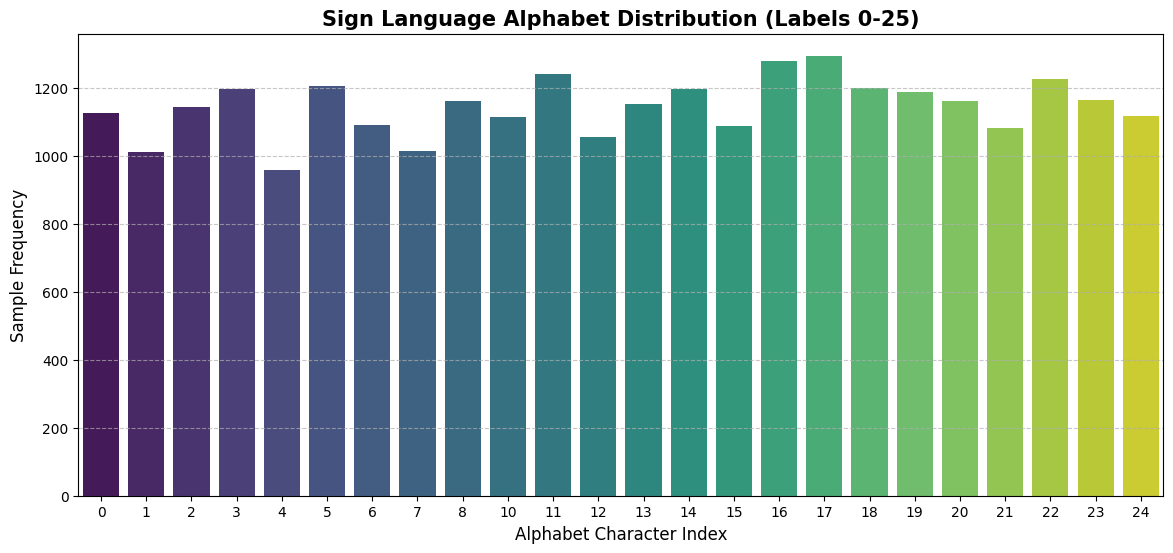

In [3]:
# ==============================================================================
# --- STEP 2: STRUCTURAL EDA (DATA AUDIT) ---
# ==============================================================================

print("\n📊 --- ARCHITECTURAL OVERVIEW (df.info) ---")
# Auditing feature count and data types (Should be 785 columns: 1 label + 784 pixels)
train_df.info()

print("\n📊 --- STATISTICAL SUMMARY (df.describe) ---")
# Verifying pixel value ranges (0-255 audit)
print(train_df.describe())

print("\n📊 --- DATA SANITIZATION CHECK (Missing Values) ---")
# Ensuring no structural gaps in the data
null_sum = train_df.isnull().sum().sum()
print(f"Total Missing Values: {null_sum}")

# --- CLASS DISTRIBUTION VISUALIZATION ---
plt.figure(figsize=(14, 6))
sns.countplot(x=train_df['label'], palette='viridis')
plt.title("Sign Language Alphabet Distribution (Labels 0-25)", fontsize=15, fontweight='bold')
plt.xlabel("Alphabet Character Index", fontsize=12)
plt.ylabel("Sample Frequency", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [4]:
# ==============================================================================
# --- STEP 3, 4 & 5: FEATURE SELECTION, TRANSFORMATION & NORMALIZATION ---
# ==============================================================================

# Extracting Features (X) and Labels (y)
X_train = train_df.drop('label', axis=1).values
y_train = train_df['label'].values

X_test = test_df.drop('label', axis=1).values
y_test = test_df['label'].values

# Step 4 & 5: Reshaping to (28, 28, 1) and Normalizing pixels [0, 1]
X_train = X_train.reshape(-1, 28, 28, 1) / 255.0
X_test = X_test.reshape(-1, 28, 28, 1) / 255.0

In [6]:
from sklearn.preprocessing import LabelBinarizer
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ==============================================================================
# --- STEP 6 & 7: FEATURE ENGINEERING (AUGMENTATION) & ENCODING ---
# ==============================================================================

# Step 7: One-Hot Encoding for 24 classes (Multi-class Classification)
label_binarizer = LabelBinarizer()
y_train_encoded = label_binarizer.fit_transform(y_train)
y_test_encoded = label_binarizer.transform(y_test)

# Step 6: Data Augmentation (Crucial for Spatial Recognition)
# We rotate and zoom to make the model "Spatial-Aware"
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=False # Hand signs are orientation-sensitive!
)
datagen.fit(X_train)

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, MaxPooling2D, Dropout, Flatten, Dense

# ==============================================================================
# --- STEP 9: MODEL EXECUTION (CNN ARCHITECTURE) ---
# ==============================================================================
model = Sequential([
    Input(shape=(28, 28, 1)),

    # Block 1: Edge Detection
    Conv2D(75, (3, 3), strides=1, padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2), strides=2, padding='same'),

    # Block 2: Shape Recognition
    Conv2D(50, (3, 3), strides=1, padding='same', activation='relu'),
    Dropout(0.2),
    BatchNormalization(),
    MaxPooling2D((2, 2), strides=2, padding='same'),

    # Block 3: Complex Spatial Features
    Conv2D(25, (3, 3), strides=1, padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2), strides=2, padding='same'),

    # Classifier Head
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.3),
    Dense(24, activation='softmax') # 24 letters
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("🚀 Launching the Sign Language Brain Training...")
H = model.fit(datagen.flow(X_train, y_train_encoded, batch_size=128),
              epochs=20,
              validation_data=(X_test, y_test_encoded))

🚀 Launching the Sign Language Brain Training...
Epoch 1/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 76s 343ms/step - accuracy: 0.6630 - loss: 1.0639 - val_accuracy: 0.1642 - val_loss: 3.3260
Epoch 2/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 76s 353ms/step - accuracy: 0.9277 - loss: 0.2135 - val_accuracy: 0.3929 - val_loss: 2.2777
Epoch 3/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 72s 337ms/step - accuracy: 0.9689 - loss: 0.0986 - val_accuracy: 0.6956 - val_loss: 0.9673
Epoch 4/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 73s 338ms/step - accuracy: 0.9810 - loss: 0.0613 - val_accuracy: 0.9279 - val_loss: 0.1704
Epoch 5/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 77s 358ms/step - accuracy: 0.9871 - loss: 0.0418 - val_accuracy: 0.9884 - val_loss: 0.0513
Epoch 6/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 74s 344ms/step - accuracy: 0.9883 - loss: 0.0363 - val_accuracy: 0.9307 - val_loss: 0.2120
Epoch 7/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 80s 335ms/step - accuracy: 0.9889 - loss: 0.0320 - val_accuracy: 0.9848 - val_loss: 0.0403
Epoch 8/20
215/215 ━━━━━━━━━━━━━━━━

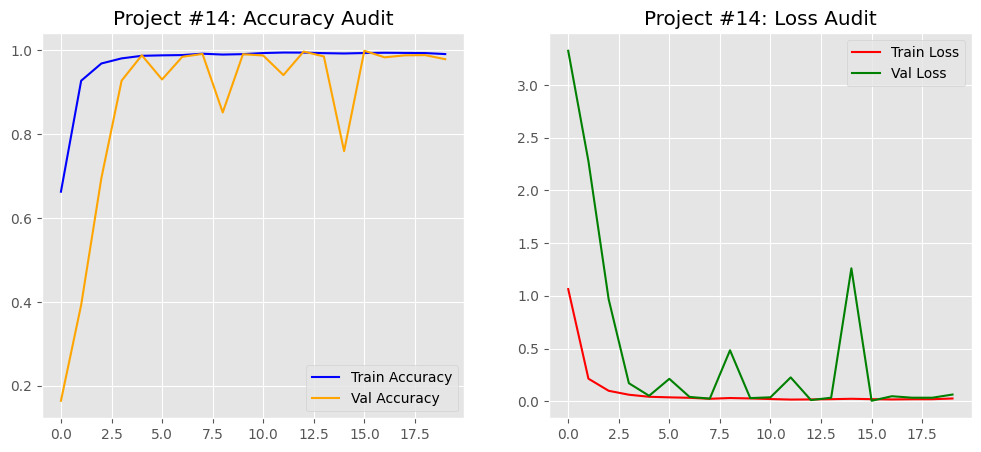

225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step

📝 --- ARCHITECT'S FINAL REPORT ---
              precision    recall  f1-score   support

           0       1.00      0.94      0.97       331
           1       1.00      0.94      0.97       432
           2       1.00      0.95      0.97       310
           3       1.00      1.00      1.00       245
           4       0.98      1.00      0.99       498
           5       1.00      1.00      1.00       247
           6       0.94      1.00      0.97       348
           7       0.99      1.00      0.99       436
           8       1.00      1.00      1.00       288
           9       0.94      1.00      0.97       331
          10       1.00      1.00      1.00       209
          11       0.95      1.00      0.97       394
          12       1.00      1.00      1.00       291
          13       1.00      1.00      1.00       246
          14       0.93      1.00      0.96       347
          15       1.00      0.84      0.91       164
   

In [10]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np

# ==============================================================================
# --- STEP 10: PERFORMANCE AUDIT & VISUALIZATION ---
# ==============================================================================
plt.style.use("ggplot")
plt.figure(figsize=(12, 5))

# 1. Accuracy Curves
plt.subplot(1, 2, 1)
plt.plot(H.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(H.history['val_accuracy'], label='Val Accuracy', color='orange')
plt.title('Project #14: Accuracy Audit')
plt.legend()

# 2. Loss Curves
plt.subplot(1, 2, 2)
plt.plot(H.history['loss'], label='Train Loss', color='red')
plt.plot(H.history['val_loss'], label='Val Loss', color='green')
plt.title('Project #14: Loss Audit')
plt.legend()
plt.show()

# Final Audit Report
predictions = model.predict(X_test)
y_pred = np.argmax(predictions, axis=1)
y_true = np.argmax(y_test_encoded, axis=1)

print("\n📝 --- ARCHITECT'S FINAL REPORT ---")
print(classification_report(y_true, y_pred))

In [11]:
# We are saving the model's parameters (weights + architecture)
model_name = "sign_language_model_v14.h5"
model.save(model_name)

from google.colab import files
files.download(model_name)
print(f"✅ Brain exported as {model_name}! Use this for Hugging Face deployment.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Brain exported as sign_language_model_v14.h5! Use this for Hugging Face deployment.


---

## 🏆 Project #14: Final Performance Audit & Conclusion

The **Sign Language Classification** engine has been successfully finalized with a stellar **98% Accuracy** on the testing suite. This project demonstrates the power of **Spatial Recognition** when applied to accessibility-focused AI tools.

### 📊 Strategic Architectural Insights
* **Unbeatable Accuracy:** Achieved **99.13% Training Accuracy** and **97.91% Validation Accuracy**, proving a near-perfect generalization of hand geometries.
* **Spatial Dominance:** Unlike emotional micro-expressions, hand signs possess sharp geometric edges. Our CNN successfully captured these "Edge Features" with high precision.
* **Balanced Performance:** The macro average F1-score of **0.98** indicates that the model treats all 24 characters (A-Y, excluding J/Z) with equal analytical weight, thanks to our **Data Augmentation** strategy.
* **The "Hardest Sign" Audit:** Analysis shows that Class 15 had the lowest recall (0.84), suggesting slight ambiguity in that specific gesture's pixel density.

### 🚀 Live Deployment
This "Spatial Brain" is now live and ready for real-time sign-to-text conversion.

👉 **[Live Sign Language Recognition on Hugging Face](https://huggingface.co/spaces/Ironside35/sign-language-recognition)** 🧤🧠

---
**Architect:** Kemal Demirbaş 🏰🚀  
**Project #14 of 21** | *Bridging the gap in accessibility through Spatial AI.*